In [1]:
import CAST
import scanpy as sc
import os
import numpy as np
import warnings
import dgl
import torch
import CAST
import os
import numpy as np
import anndata as ad
import scanpy as sc
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
work_dir = '/p1/data/jtian/SA/05_CAST' #### input the demo path
output_path = f'{work_dir}/output_castProj1'
os.makedirs(output_path,exist_ok=True)
graph_list = {'rep1':['15','0']} # source_sample, target_sample
import scanpy as sc
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
cell_label_dict = torch.load("/p1/data/jtian/SA/05_CAST/output_castProj1/cell_label_dict_k20.pt", map_location="cpu")

In [3]:
cell_label_dict

{'0': array([ 5,  5,  5, ...,  0,  0, 19], dtype=int32),
 '15': array([ 5,  5,  5, ..., 19, 19,  5], dtype=int32),
 '30': array([5, 5, 5, ..., 5, 5, 5], dtype=int32),
 '45': array([5, 5, 5, ..., 5, 5, 5], dtype=int32),
 '60': array([5, 5, 5, ..., 5, 5, 5], dtype=int32)}

In [43]:
adata = ad.read_h5ad("/p2/zulab/jtian/data/SA/05_CAST/output_cast9/demo1_cast9.h5ad") 

In [44]:
adata.obs

,x,y,sample
SpotIndex,,,
1,49939,5370,0
2,49959,5370,0
3,49979,5370,0
4,49999,5370,0
5,50019,5370,0
...,...,...,...
247357,3119,4970,60
247358,3139,4970,60
247359,3159,4970,60


In [45]:
sample_order = ['0','15','30','45','60']
cell_label = np.concatenate([cell_label_dict[k] for k in sample_order])
adata.obs['cell_label'] = cell_label

In [46]:
adata.obs

,x,y,sample,cell_label
SpotIndex,,,,
1,49939,5370,0,5
2,49959,5370,0,5
3,49979,5370,0,5
4,49999,5370,0,5
5,50019,5370,0,5
...,...,...,...,...
247357,3119,4970,60,5
247358,3139,4970,60,5
247359,3159,4970,60,5


In [15]:
intensity0 = pd.read_csv("/p2/zulab/jtian/data/SA/05_CAST/input/MetaboliteIntensity/01-intensityRMS.csv", sep=";", header = 0, index_col = 0)
intensity0 = intensity0.T
intensity0.index = intensity0.index.str.replace('Spot','',regex=False).str.strip().astype(int)

intensity15 = pd.read_csv("/p2/zulab/jtian/data/SA/05_CAST/input/MetaboliteIntensity/02-intensityRMS.csv", sep=";", header = 0, index_col = 0)
intensity15 = intensity15.T
intensity15.index = intensity15.index.str.replace('Spot','',regex=False).str.strip().astype(int)

intensity30 = pd.read_csv("/p2/zulab/jtian/data/SA/05_CAST/input/MetaboliteIntensity/03-intensityRMS.csv", sep=";", header=0, index_col=0)
intensity30 = intensity30.T
intensity30.index = intensity30.index.str.replace('Spot', '', regex=False).str.strip().astype(int)

intensity45 = pd.read_csv("/p2/zulab/jtian/data/SA/05_CAST/input/MetaboliteIntensity/04-intensityRMS.csv", sep=";", header=0, index_col=0)
intensity45 = intensity45.T
intensity45.index = intensity45.index.str.replace('Spot', '', regex=False).str.strip().astype(int)

intensity60 = pd.read_csv("/p2/zulab/jtian/data/SA/05_CAST/input/MetaboliteIntensity/05-intensityRMS.csv", sep=";", header=0, index_col=0)
intensity60 = intensity60.T
intensity60.index = intensity60.index.str.replace('Spot', '', regex=False).str.strip().astype(int)

In [17]:
intensity0.columns.name = None
intensity15.columns.name = None
intensity30.columns.name = None
intensity45.columns.name = None
intensity60.columns.name = None

In [20]:
print("\n--- 数据预览 (Head & Tail) ---")

print("样本 0 - 前 5 行:")
print(intensity0.iloc[:5, :7])
print("样本 0 - 后 5 行:")
print(intensity0.iloc[-5:, :7])

print("\n样本 15 - 前 5 行:")
print(intensity15.iloc[:5, :7])
print("样本 15 - 后 5 行:")
print(intensity15.iloc[-5:, :7])

print("\n样本 30 - 前 5 行:")
print(intensity30.iloc[:5, :7])
print("样本 30 - 后 5 行:")
print(intensity30.iloc[-5:, :7])

print("\n样本 45 - 前 5 行:")
print(intensity45.iloc[:5, :7])
print("样本 45 - 后 5 行:")
print(intensity45.iloc[-5:, :7])

print("\n样本 60 - 前 5 行:")
print(intensity60.iloc[:5, :7])
print("样本 60 - 后 5 行:")
print(intensity60.iloc[-5:, :7])



--- 数据预览 (Head & Tail) ---
样本 0 - 前 5 行:
    57.0346   58.0296   59.0139   67.0191   71.0137   71.0503   72.0091
1  0.208880  0.254289  0.499496  0.399597  1.607469  0.127144  0.962665
2  0.000000  0.223221  0.480784  0.257563  2.481191  0.000000  1.210547
3  0.000000  0.000000  1.175326  0.720719  0.698543  0.000000  0.155232
4  0.152048  0.000000  0.557510  0.000000  0.726453  0.000000  0.278755
5  0.000000  0.000000  0.725190  0.382195  2.587164  0.000000  0.000000
样本 0 - 后 5 行:
        57.0346   58.0296   59.0139   67.0191    71.0137   71.0503   72.0091
47391  0.000000  0.717167  4.328612  0.640327  16.008182  0.947684  2.177113
47392  0.998003  0.000000  3.669128  3.404951  22.132178  0.000000  0.000000
47393  0.954880  1.432320  4.190861  0.981404  12.360387  0.000000  2.466773
47394  1.149264  2.667935  7.798578  1.477625  23.518871  0.000000  1.231354
47395  0.000000  0.000000  3.199748  0.946864  17.500664  0.000000  2.742641

样本 15 - 前 5 行:
        57.0346   58.0296   59.013

In [21]:
intensity = pd.concat([intensity0,intensity15,intensity30,intensity45,intensity60])

In [23]:
print(intensity.head(5).iloc[:,:7])
print(intensity.tail(5).iloc[:,:7])

    57.0346   58.0296   59.0139   67.0191   71.0137   71.0503   72.0091
1  0.208880  0.254289  0.499496  0.399597  1.607469  0.127144  0.962665
2  0.000000  0.223221  0.480784  0.257563  2.481191  0.000000  1.210547
3  0.000000  0.000000  1.175326  0.720719  0.698543  0.000000  0.155232
4  0.152048  0.000000  0.557510  0.000000  0.726453  0.000000  0.278755
5  0.000000  0.000000  0.725190  0.382195  2.587164  0.000000  0.000000
         57.0346   58.0296    59.0139   67.0191    71.0137   71.0503   72.0091
247357  2.105920  0.399399  10.329899  2.178538  39.013979  1.216350  4.302612
247358  2.115093  0.459090  16.691198  1.278893  49.745672  2.672559  4.115413
247359  1.906487  2.017329  14.121301  2.793224  41.831861  0.532043  6.916556
247360  1.522979  3.635498   7.148176  0.000000  30.975429  1.007131  2.554675
247361  1.155611  1.129931  10.631622  2.413943  31.869185  0.000000  0.000000


In [47]:
intensity.shape

(247361, 696)

In [48]:
adata.obs.shape

(247361, 4)

In [49]:
intensity.index[:5]

Index([1, 2, 3, 4, 5], dtype='int64')

In [50]:
adata.obs.index[:5]

Index(['1', '2', '3', '4', '5'], dtype='object', name='SpotIndex')

In [51]:
adata.obs.index = adata.obs.index.astype(int)
adata.obs.index.name = None


In [52]:
adata.obs.index[:5]

Index([1, 2, 3, 4, 5], dtype='int64')

In [53]:
coordsLabelIntensity = pd.concat([adata.obs,intensity],axis=1)

In [54]:
coordsLabelIntensity

,x,y,sample,cell_label,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
1,49939,5370,0,5,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
2,49959,5370,0,5,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
3,49979,5370,0,5,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
4,49999,5370,0,5,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
5,50019,5370,0,5,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247357,3119,4970,60,5,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247358,3139,4970,60,5,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247359,3159,4970,60,5,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247360,3179,4970,60,5,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [55]:
coordsLabelIntensity = coordsLabelIntensity.iloc[:, 2:]
coordsLabelIntensity.to_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/coordsLabelIntensity.csv")


In [56]:
coordsLabelIntensity

,sample,cell_label,57.0346,58.0296,59.0139,67.0191,71.0137,71.0503,72.0091,72.017,...,856.5052,859.5297,860.536,863.5618,864.5684,882.5853,921.5991,923.615,985.6046,986.6105
1,0,5,0.208880,0.254289,0.499496,0.399597,1.607469,0.127144,0.962665,0.354188,...,0.363270,0.481332,0.163471,0.000000,0.435924,0.308779,0.000000,0.000000,0.163471,0.000000
2,0,5,0.000000,0.223221,0.480784,0.257563,2.481191,0.000000,1.210547,0.000000,...,0.712591,0.154538,0.283319,0.394930,0.463614,0.257563,0.154538,0.000000,0.120196,0.412101
3,0,5,0.000000,0.000000,1.175326,0.720719,0.698543,0.000000,0.155232,0.000000,...,0.177408,0.155232,0.221760,0.410255,0.000000,0.000000,0.000000,0.232848,0.654191,0.343727
4,0,5,0.152048,0.000000,0.557510,0.000000,0.726453,0.000000,0.278755,0.143601,...,0.084471,0.000000,0.194284,0.304097,0.464592,0.312544,0.278755,0.000000,0.000000,0.000000
5,0,5,0.000000,0.000000,0.725190,0.382195,2.587164,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.088199,0.244997,0.244997,0.195997,0.000000,0.391995,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247357,60,5,2.105920,0.399399,10.329899,2.178538,39.013979,1.216350,4.302612,0.000000,...,4.393384,5.627889,0.000000,3.558278,1.670212,2.723172,1.379741,1.760985,3.739823,2.360082
247358,60,5,2.115093,0.459090,16.691198,1.278893,49.745672,2.672559,4.115413,0.000000,...,3.148045,4.640087,0.000000,3.672719,2.623371,1.869152,1.721587,0.950972,4.230186,2.229865
247359,60,5,1.906487,2.017329,14.121301,2.793224,41.831861,0.532043,6.916556,0.000000,...,3.591289,5.918976,5.054406,4.655374,2.083834,1.950823,2.394192,1.773476,5.409101,2.726719
247360,60,5,1.522979,3.635498,7.148176,0.000000,30.975429,1.007131,2.554675,0.000000,...,8.622027,11.299522,7.393818,7.614895,4.102218,6.091916,2.309033,1.940570,5.035657,2.972266


In [60]:

intensity_cols = coordsLabelIntensity.columns[2:]

mean_df = (
    coordsLabelIntensity
    .groupby(['sample', 'cell_label'], as_index=False)[intensity_cols]
    .mean()
)

print(mean_df.shape)
print(mean_df.head())


(100, 698)
  sample  cell_label   57.0346   58.0296   59.0139   67.0191    71.0137  \
0      0           0  0.672462  1.183939  4.577493  1.168264  20.045918   
1      0           1  0.752187  1.072616  4.595960  1.191684  19.786215   
2      0           2  0.683904  1.141187  4.172232  1.154756  23.878928   
3      0           3  0.703112  1.114269  4.683331  1.190811  20.012604   
4      0           4  0.688240  1.055766  4.348649  1.175488  19.199055   

    71.0503   72.0091    72.017  ...  856.5052  859.5297   860.536  863.5618  \
0  0.480590  1.697932  0.645136  ...  3.320776  5.452214  3.565698  3.404137   
1  0.520111  1.733355  0.630506  ...  3.031339  5.103012  3.655685  4.137252   
2  0.420280  1.501936  0.782014  ...  2.753793  4.326700  3.036067  4.076641   
3  0.551027  1.742869  0.656919  ...  3.179967  5.395672  3.881061  3.778225   
4  0.496135  1.592741  0.612507  ...  3.384962  5.765283  3.906989  3.456079   

   864.5684  882.5853  921.5991   923.615  985.6046  986.

In [61]:
mean_df.to_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/meanBySampleByCluster.csv")

In [62]:
sample_order = [0, 15, 30, 45, 60]   
intensity_cols = mean_df.columns[2:]  
def linreg_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    n = len(x)
    if n < 2:
        return np.nan, np.nan, np.nan, np.nan

    xm = x.mean()
    ym = y.mean()
    dx = x - xm
    dy = y - ym

    varx = np.sum(dx * dx)
    if varx == 0:
        return np.nan, np.nan, np.nan, np.nan

    slope = np.sum(dx * dy) / varx
    intercept = ym - slope * xm

    yhat = slope * x + intercept
    ss_res = np.sum((y - yhat) ** 2)
    ss_tot = np.sum((y - ym) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    # y=0 时 x 截距：x0 = -b/a；取绝对值
    x0_abs = np.abs(-intercept / slope) if slope != 0 else np.nan
    return slope, intercept, r2, x0_abs

In [63]:
# index=(cell_label, sample)，columns=代谢物
mat = (
    mean_df
    .assign(sample=lambda d: d['sample'].astype(float),
            cell_label=lambda d: d['cell_label'].astype(int))
    .set_index(['cell_label', 'sample'])[list(intensity_cols)]
    .sort_index()
)

x = np.array(sample_order, dtype=float)


In [ ]:
results = []

for label in mat.index.get_level_values('cell_label').unique():
    sub = mat.loc[label].reindex(sample_order)  # 行是 sample，列是代谢物

    for mz in sub.columns:
        y = sub[mz].values
        slope, intercept, r2, x0_abs = linreg_stats(x, y)
        results.append({
            'cell_label': label,
            'metabolite': mz,
            'slope': slope,
            'intercept': intercept,
            'r2': r2,
            'x_intercept_abs': x0_abs,
        })

fit_df = pd.DataFrame(results)
fit_df.head()


,cell_label,metabolite,slope,intercept,r2,x_intercept_abs
0,0,57.0346,0.003527,0.705880,0.907794,200.142660
1,0,58.0296,0.003187,1.190263,0.985569,373.429464
2,0,59.0139,0.029362,4.687160,0.982371,159.631240
3,0,67.0191,0.006428,1.159766,0.988506,180.419492
4,0,71.0137,0.102377,19.873646,0.994644,194.121509


In [67]:
fit_df = fit_df.set_index(['cell_label', 'metabolite'])

fit_df = fit_df.reorder_levels(['metabolite', 'cell_label']).sort_index()



In [68]:
fit_df

slope  intercept        r2  x_intercept_abs
metabolite cell_label                                                
57.0346    0           0.003527   0.705880  0.907794       200.142660
           1           0.001779   0.767512  0.899240       431.361201
           2           0.003082   0.720228  0.789031       233.726090
           3           0.003068   0.726753  0.910105       236.864606
           4           0.003450   0.706171  0.957983       204.671025
...                         ...        ...       ...              ...
986.6105   15          0.009191   1.155616  0.921246       125.734535
           16          0.007639   1.143232  0.724794       149.661418
           17          0.011411   1.133819  0.893816        99.364934
           18          0.009748   1.121760  0.851863       115.070806
           19          0.013973   0.943231  0.901126        67.504395

[13920 rows x 4 columns]

In [71]:
fit_df.to_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/relativeConcentration.csv")


In [6]:
fit_df = pd.read_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/relativeConcentration.csv")


In [7]:
fit_df

,metabolite,cell_label,slope,intercept,r2,x_intercept_abs
0,57.0346,0,0.003527,0.705880,0.907794,200.142660
1,57.0346,1,0.001779,0.767512,0.899240,431.361201
2,57.0346,2,0.003082,0.720228,0.789031,233.726090
3,57.0346,3,0.003068,0.726753,0.910105,236.864606
4,57.0346,4,0.003450,0.706171,0.957983,204.671025
...,...,...,...,...,...,...
13915,986.6105,15,0.009191,1.155616,0.921246,125.734535
13916,986.6105,16,0.007639,1.143232,0.724794,149.661418
13917,986.6105,17,0.011411,1.133819,0.893816,99.364934
13918,986.6105,18,0.009748,1.121760,0.851863,115.070806


In [9]:
r2MeanByMeta = fit_df.groupby('metabolite')['r2'].mean()

In [10]:
r2_thr = r2MeanByMeta[r2MeanByMeta >= 0.9]

In [13]:
r2_thr.to_csv("/p2/zulab/jtian/data/SA/06_calculateConcentration/output_calculateByClusterLR/ctrl3GoodMeanR2_ge_0.9.csv")

Top10 by R2:
       metabolite  cell_label     slope  intercept        r2  x_intercept_abs
8511     352.0792          11  0.016619   1.504042  0.999927        90.504066
3284     176.9358           4  0.135025   6.536078  0.999900        48.406575
6821     288.0406           1  0.014607   0.753806  0.999788        51.604670
3279     176.8571          19  0.015197   0.245768  0.999787        16.172503
4583     223.0267           3  0.029255   1.796537  0.999747        61.409563
6580     278.2198           0  0.058271   1.014003  0.999744        17.401589
11040    511.2511           0  0.047374   7.415041  0.999705       156.521000
120       72.0091           0  0.010342   1.700958  0.999669       164.466621
9864     457.2572           4  0.088020   1.575831  0.999647        17.903146
9655     444.3204          15  0.008960   0.523514  0.999628        58.425909


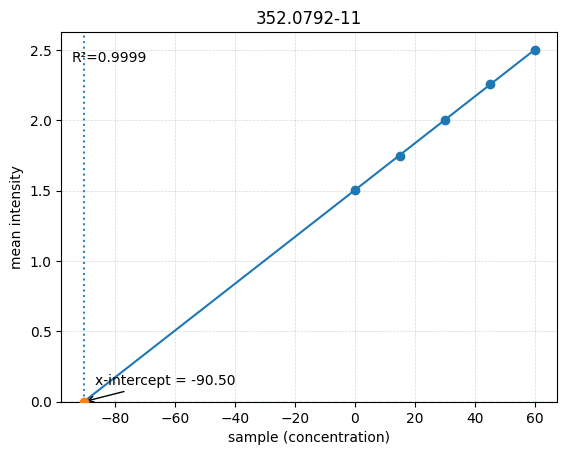

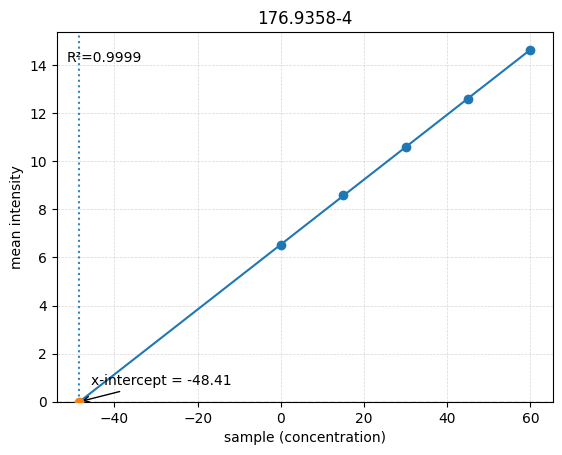

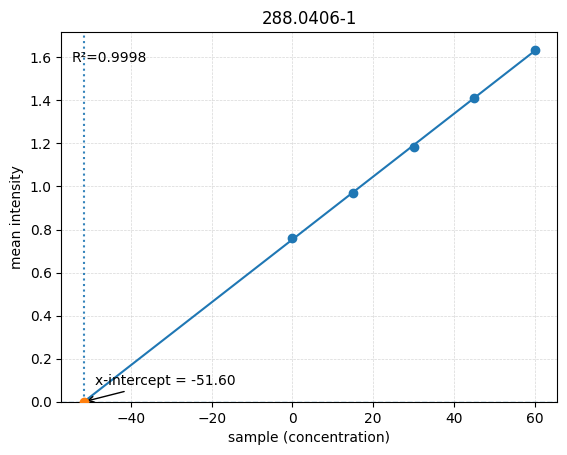

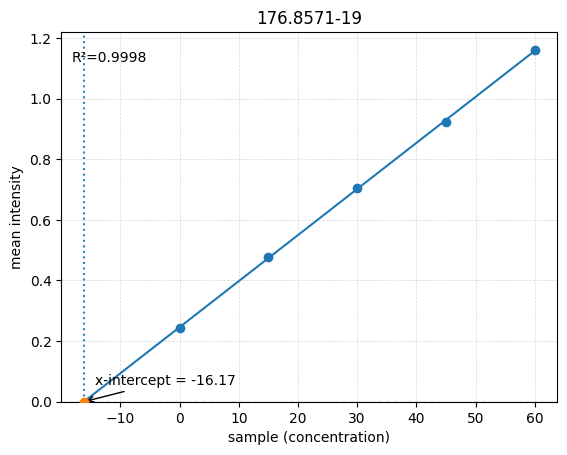

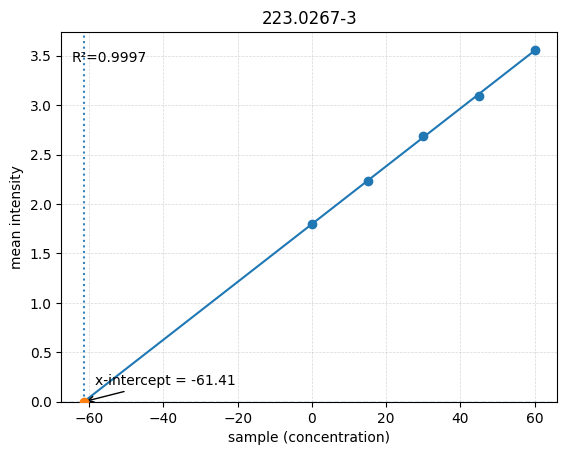

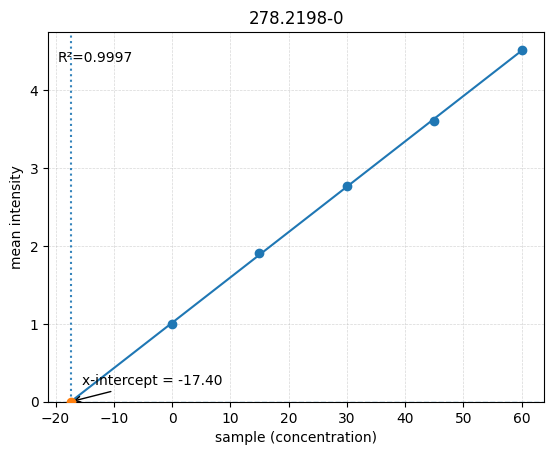

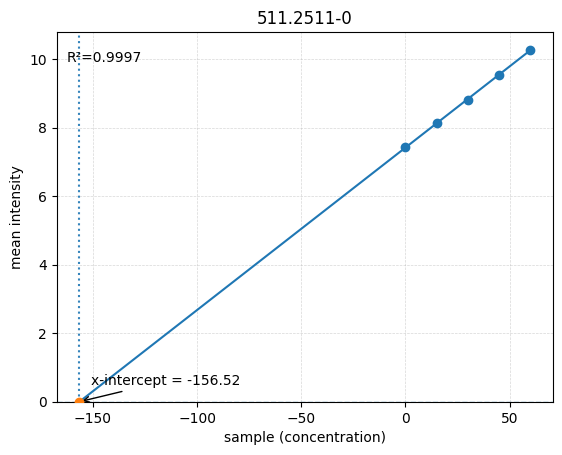

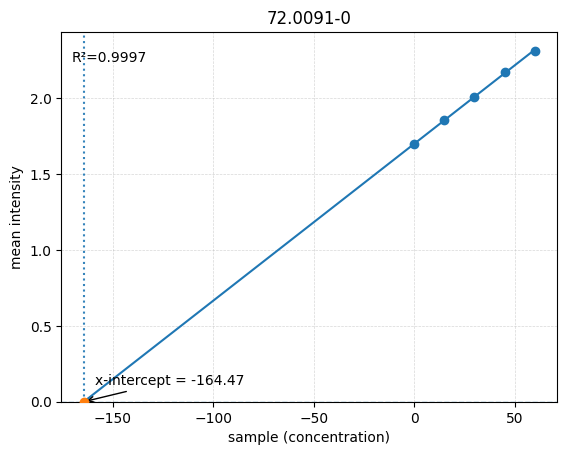

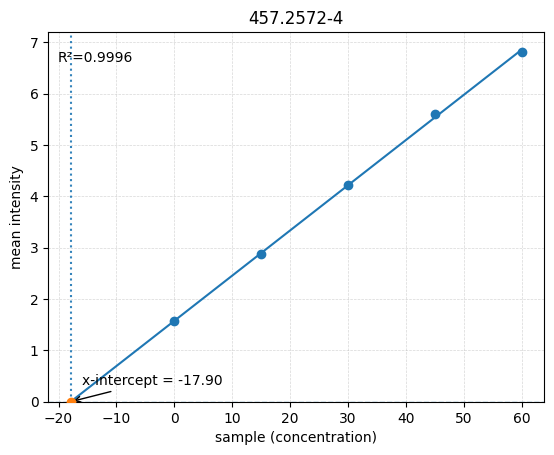

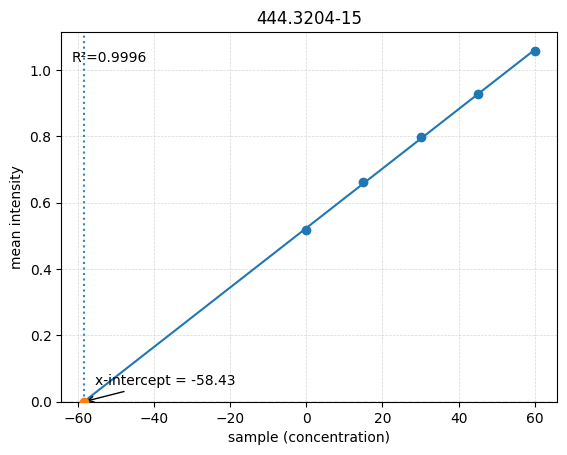

In [75]:
sample_order = [0, 15, 30, 45, 60]
x = np.array(sample_order, dtype=float)

# --- 1) 取 R2 最高的前 10 条拟合结果 ---
# 兼容 fit_df 可能是 MultiIndex 或普通列
tmp = fit_df.reset_index() if isinstance(fit_df.index, pd.MultiIndex) else fit_df.copy()

top5 = (
    tmp.dropna(subset=['r2'])
       .sort_values('r2', ascending=False)
       .head(10)
)

print("Top10 by R2:")
print(top5[['metabolite','cell_label','slope','intercept','r2','x_intercept_abs']])

# --- 2) 逐条画标准曲线（带横截距标注，y轴从0开始） ---
for _, row in top5.iterrows():
    mz = row['metabolite']
    label = int(row['cell_label'])
    slope = float(row['slope'])
    intercept = float(row['intercept'])
    r2 = float(row['r2'])

    # 从 mean_df 取该 cell_label、该 mz 在 5 个 sample 下的均值强度
    sub = mean_df.loc[mean_df['cell_label'].astype(int) == label, ['sample', mz]].copy()
    sub['sample'] = sub['sample'].astype(float)

    # 确保按 sample_order 排序对齐；缺失则会是 NaN
    sub = sub.set_index('sample').reindex(sample_order)
    y = sub[mz].to_numpy(dtype=float)

    # 计算横截距（y=0时的x）
    x0 = np.nan
    if np.isfinite(slope) and slope != 0:
        x0 = -intercept / slope

    # 拟合线：延伸到横截距（如果横截距在0左侧，也能显示出来）
    x_left = min(x.min(), x0) if np.isfinite(x0) else x.min()
    x_line = np.linspace(x_left, x.max(), 300)
    y_line = slope * x_line + intercept

    # 一张图画一条曲线
    plt.figure()
    plt.scatter(x, y, zorder=3)
    plt.plot(x_line, y_line, zorder=2)

    plt.title(f"{mz}-{label}")
    plt.xlabel("sample (concentration)")
    plt.ylabel("mean intensity")

    # y轴从0开始
    plt.ylim(bottom=0)

    # 标注R2
    plt.text(0.02, 0.95, f"R²={r2:.4f}", transform=plt.gca().transAxes, va='top')

    # 画x轴参考线（y=0）
    plt.axhline(0, linestyle='--', linewidth=1, alpha=0.7)

    # 标记横截距：竖线 + 点 + 箭头注释
    if np.isfinite(x0):
        plt.axvline(x0, linestyle=':', linewidth=1.5, alpha=0.9)
        plt.scatter([x0], [0], zorder=4)
        plt.annotate(
            f"x-intercept = {x0:.2f}",
            xy=(x0, 0),
            xytext=(8, 12),
            textcoords='offset points',
            arrowprops=dict(arrowstyle='->')
        )

    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
    plt.show()
